In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [2]:
patch_size = 50
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
max_skew = 0

margin = 500
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
batch_size = 256
epochs = 100000
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [3]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [4]:
def get_random_homography_matrix():
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//10) * 10
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [5]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            img = cv2.imread(os.path.join(image_dir_path, image))
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            img = img/255
            self.img_list.append(img)
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        for _ in range(self.batchsize):
            current_image_no = np.random.randint(0, len(self.img_list))
            current_image = self.img_list[current_image_no]
            x = np.random.randint(0,image_size - patch_size)
            y = np.random.randint(0,image_size - patch_size)
            current_patch = current_image[x:x+patch_size, y:y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            X = np.random.randint(0,image_size - patch_size)
            Y = np.random.randint(0,image_size - patch_size)
            random_image_no = np.random.randint(0, len(self.img_list))
            random_image = self.img_list[random_image_no]
            while(x==X & y==Y & random_image_no == current_image_no):
                X = np.random.randint(0,image_size - patch_size)
                Y = np.random.randint(0,image_size - patch_size)
                
            current_patch = random_image[X:X+patch_size, Y:Y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)
        
            original_images = np.array(original_images)
            matches = np.array(matches)
            non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

In [6]:
# class ChannelNormalization(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ChannelNormalization, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.l2_normalize(inputs, axis=-1)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ChannelNormalization, self).build(input_shape)
        
#     def get_config(self):
#         return super(ChannelNormalization, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [7]:
# class ClippingLayer(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ClippingLayer, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.clip(inputs, min_value=0.0, max_value=256.0)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ClippingLayer, self).build(input_shape)
        
#     def get_config(self):
#         return super(ClippingLayer, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [8]:
# def get_model(input_shape, descriptor_dimension):
#     inp = tf.keras.layers.Input(input_shape)
#     out = tf.keras.layers.Conv2D(descriptor_dimension, kernel_size)(inp)
#     # out = ClippingLayer()(out)
#     out = ChannelNormalization()(out)
    
#     model = tf.keras.models.Model(inputs = inp, outputs = out)
#     return model

In [9]:
# def custom_loss(original_desc, matches, non_matches):
#     original_desc = tf.squeeze(original_desc)
#     matches = tf.squeeze(matches)
#     non_matches = tf.squeeze(non_matches)
    
#     return tf.reduce_mean((1 - tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(matches, tf.transpose(non_matches))))
    

In [10]:
# model = get_model((patch_size, patch_size, 1), descriptor_dimension)
# model.summary()

In [11]:
# data_gen = CustomDataGenerator("test/img/cinema1.jpeg", batch_size)

# for epoch in range(epochs):
#     epoch_loss = 0
#     print(f"Epoch {epoch} starting...")
#     for batch in range(data_gen.__len__()):
#         all_patches, matches, non_matches = data_gen.__getitem__(batch)
#         with tf.GradientTape() as tape:
#             all_predictions = model(all_patches)
#             matches_predictions = model(matches)
#             non_matches_predictions = model(non_matches)
#             loss = custom_loss(all_predictions, matches_predictions, non_matches_predictions)
#             # print(loss)
#             epoch_loss += loss
#             gradients = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
#         # if batch%5==0:
#         #     print(loss.numpy())
#     # val_generator.on_epoch_end()
    
#     try:
#         model.save(model_path)
#         model.save(backup_model_path)
#     except Exception as e:
#         print("========= Note ================")
#         print("cant save last model")
#         print(e)
    
#     print(epoch_loss.numpy()/data_gen.__len__())
#     epoch_loss = 0

In [12]:
val_data_gen = CustomDataGenerator("test/img", 1)

In [13]:
# og, match, no_match = val_data_gen.__getitem__(0)
# fig, ax = plt.subplots(ncols=3, figsize = (11,5))
# # sns.heatmap(og[0,:,:,0], ax = ax[0], cbar = False, vmin=0, vmax=1)
# sns.heatmap(match[0,:,:,0], ax = ax[1], cbar = False, vmin=0, vmax=1)
# sns.heatmap(no_match[0,:,:,0], ax = ax[2], cbar = False, vmin=0, vmax=1)

In [14]:
filter = np.random.normal(0.5, 1/12, (patch_size, patch_size))
filter = np.clip(filter, 0, 1)
filter = tf.Variable(tf.convert_to_tensor(filter))

In [15]:
# sns.heatmap(filter)

In [16]:
# bce = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
# # sns.heatmap(bce)


In [17]:
def custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img):
    desc1_og_img_sum = tf.reduce_sum(desc1_og_img)
    desc1_trans_img_sum = tf.reduce_sum(desc1_trans_img)
    desc1_rand_img_sum = tf.reduce_sum(desc1_rand_img)
    loss = tf.maximum(0, abs(desc1_og_img_sum - desc1_trans_img_sum) - abs(desc1_rand_img_sum - desc1_og_img_sum) + margin)
    return loss

425.97256997515797


169.4236463060588
230.48676956815484
99.32943574171645
617.8860922163888
98.78966120657469
424.4330299581659
640.8163193523947
522.1700570075743
473.4805397804812
560.8263080348656
468.29648177164563
163.07476335848378
430.7225775218417
0.0
388.8164134611811
40.351562885631665
0.0
0.0
39.148393668672725
75.98932741702674
0.0
350.27128032188693
0.0
286.53090846054783
389.715680181233
290.57911741809767
0.0
0.0
282.8908527646927
0.0
0.0
0.0
0.0
0.0
0.0
0.0
129.2140146995148
0.0
177.0275983620154
0.0
0.0
0.0
279.5939952734964
421.22903737237857
69.82985164992078
0.0
217.75117110740757
180.3207597694509
0.0
0.0
0.0
0.0
430.84843490422827
0.0
0.0
0.0
96.81868609604226
0.0
0.0
69.0245820917703
283.8957208458455
132.0957801169884
356.4536910045276
67.66054915060977
0.0
447.22490912389503
0.0
318.86297237476447
434.0743173401852
453.46950215360084
0.0
0.0
0.0
134.57567559910103
43.50518545092518
0.0
0.0
0.0
0.0
0.0
370.56862182639134
388.52614634154816
103.92221578281487
229.72344826530662
0.0

KeyboardInterrupt: 

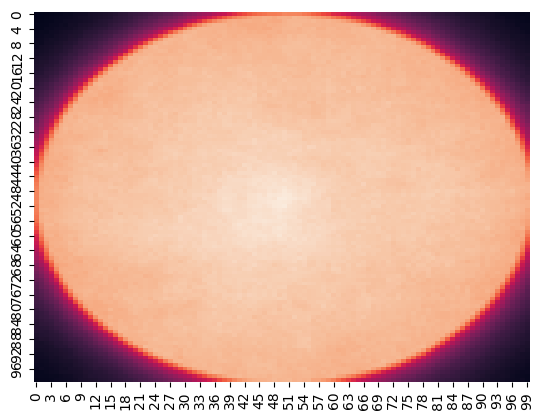

In [18]:

for i in range(epochs):
    og, match, no_match = val_data_gen.__getitem__(0)
    with tf.GradientTape() as tape:
        # desc1_og_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
        # desc1_trans_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(match[0,:,:,0], filter))
        # desc1_rand_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(no_match[0,:,:,0], filter))
        desc1_og_img = tf.multiply(og[0,:,:,0], tf.keras.activations.sigmoid(filter))
        desc1_trans_img = tf.multiply(match[0,:,:,0] , tf.keras.activations.sigmoid(filter))
        desc1_rand_img = tf.multiply(no_match[0,:,:,0] , tf.keras.activations.sigmoid(filter))
        
        loss = custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img)
        gradients = tape.gradient(loss, [filter])
        optimizer.apply_gradients(zip(gradients, [filter]))
    
    if i%500 == 0:
        sns.heatmap(filter,cbar=False)
        t = time.time()
        plt.savefig(f"filters/filter1_{int(t)}.jpg")
        # filter = tf.Variable(tf.keras.activations.sigmoid(filter))
        # optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
        # filter.assign_add(tf.random.normal((patch_size, patch_size), mean=0.0, stddev=1/12, dtype=tf.double))
        print(loss.numpy())
        

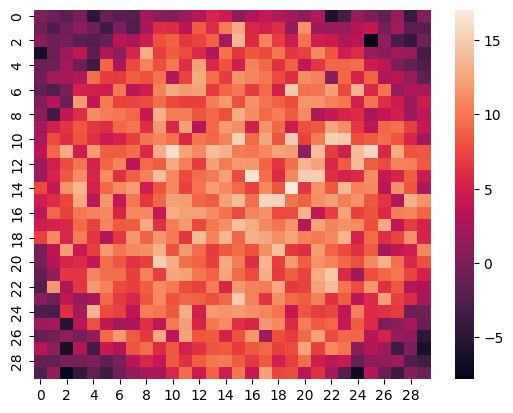

In [ ]:
sns.heatmap(filter)
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")

<Figure size 640x480 with 0 Axes>